In [ ]:
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'


  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-egy9oidi
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-egy9oidi
  Resolved https://github.com/facebookresearch/detectron2.git to commit 18f69583391e5040043ca4f4bebd2c60f0ebfde0
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 84.8 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp311-cp311-linux_x86_64.whl size=6434118 sha256=db4bcedd37bdefb71aa2643c90815498e853e8ca0c92c37a34adcac2dfc6b9b4
  Stored in directory: /tmp/pip-ephem-wheel-cache-741qhw7d/wheels/17/d9/40/60db98e485aa9455

In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks_sirisha')

In [ ]:
import importlib.util
import sys

spec = importlib.util.spec_from_file_location("utils", "/content/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["utils"] = utils
spec = importlib.util.spec_from_file_location("utils", "/content/drive/MyDrive/Colab Notebooks_sirisha/utils.py")
spec.loader.exec_module(utils)

# Now reload to make sure it's fresh
import importlib
importlib.reload(utils)

<module 'utils' from '/content/drive/MyDrive/Colab Notebooks_sirisha/utils.py'>

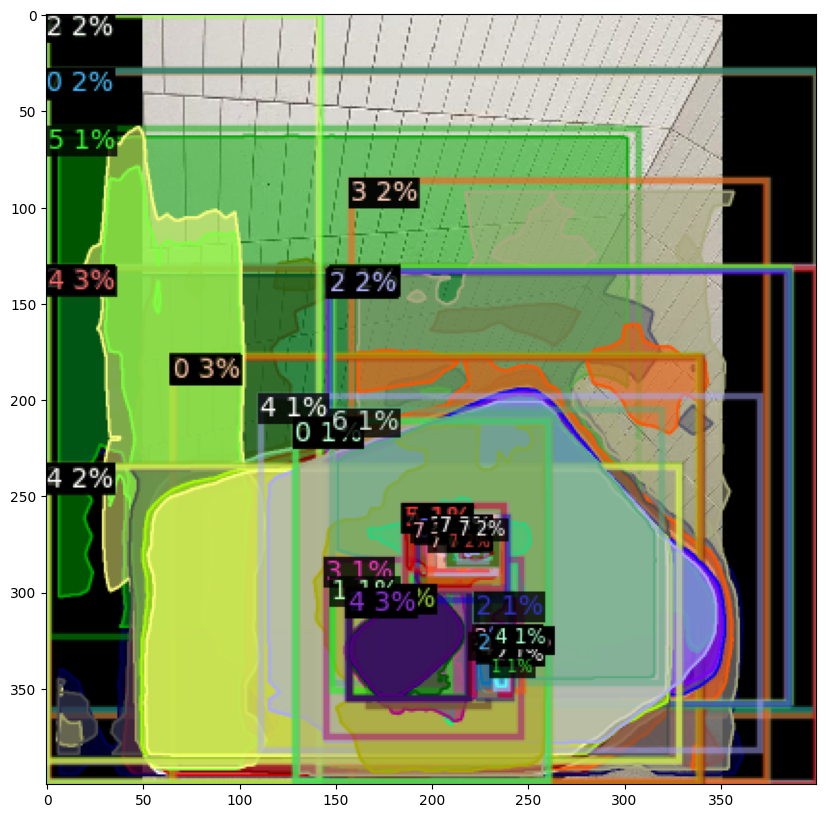

In [13]:
from detectron2.engine import DefaultPredictor
from detectron2.data.datasets import register_coco_instances

import os
import pickle

from utils import *

class_names = ["Battery Acid", "Bleach", "Coolant", "Fuel", "Hydraulic Fuel",
               "Hydrochloric Acid", "Motor Oil", "VX"]

test_dataset_name = "liquid_test"
test_json_annotation_path = "/content/drive/MyDrive/Colab Notebooks_sirisha/Spill Detection.v6i.coco-segmentation_detectron2/test_annotations.coco.json"
test_images_path = "/content/drive/MyDrive/Colab Notebooks_sirisha/Spill Detection.v6i.coco-segmentation_detectron2/test"

register_coco_instances(
    name=test_dataset_name,
    metadata={},
    json_file=test_json_annotation_path,
    image_root=test_images_path
)


metadata = MetadataCatalog.get(test_dataset_name)
metadata.set(thing_classes=class_names)

cfg_save_path = "/content/drive/MyDrive/Colab Notebooks_sirisha/Spill Detection.v6i.coco-segmentation_detectron2/IS_cfg.pickle"

with open(cfg_save_path, 'rb') as f:
    cfg = pickle.load(f)


cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.005

predictor = DefaultPredictor(cfg)

image_path = "/content/drive/MyDrive/Colab Notebooks_sirisha/Spill Detection.v6i.coco-segmentation_detectron2/test/Image-138_jpeg.rf.42a0ee591a20319782fececf36570d98.jpg"

on_image(image_path, predictor)
#on_video

In [14]:
print(outputs["instances"])


NameError: name 'outputs' is not defined